In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

In [2]:
# 1. Generate sample data
X, y_true = make_blobs(n_samples=150, centers=4, cluster_std=0.80, random_state=42)
X = StandardScaler().fit_transform(X)

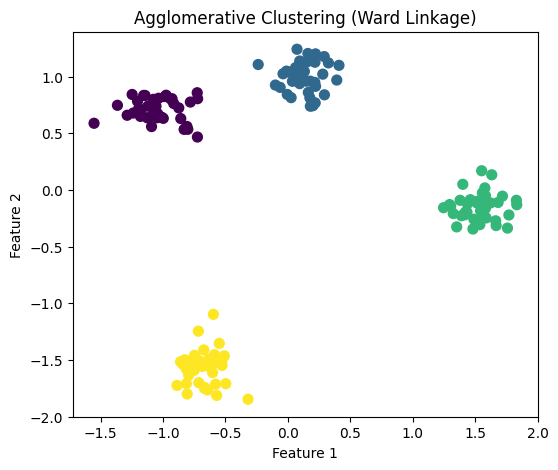

In [3]:
# 2. AGGLOMERATIVE CLUSTERING (Bottom-Up) - scikit-learn
agg_cluster = AgglomerativeClustering(n_clusters=4, linkage='ward')
agg_labels = agg_cluster.fit_predict(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=agg_labels, cmap='viridis', s=50)
plt.title("Agglomerative Clustering (Ward Linkage)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

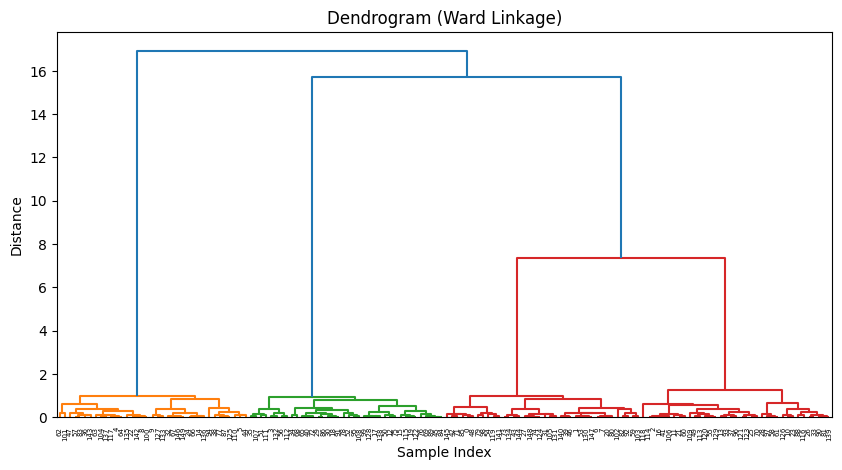

In [4]:
# 3. DENDROGRAM (for Agglomerative) - scipy
Z = linkage(X, method='ward')  # try 'single', 'complete', 'average' too

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

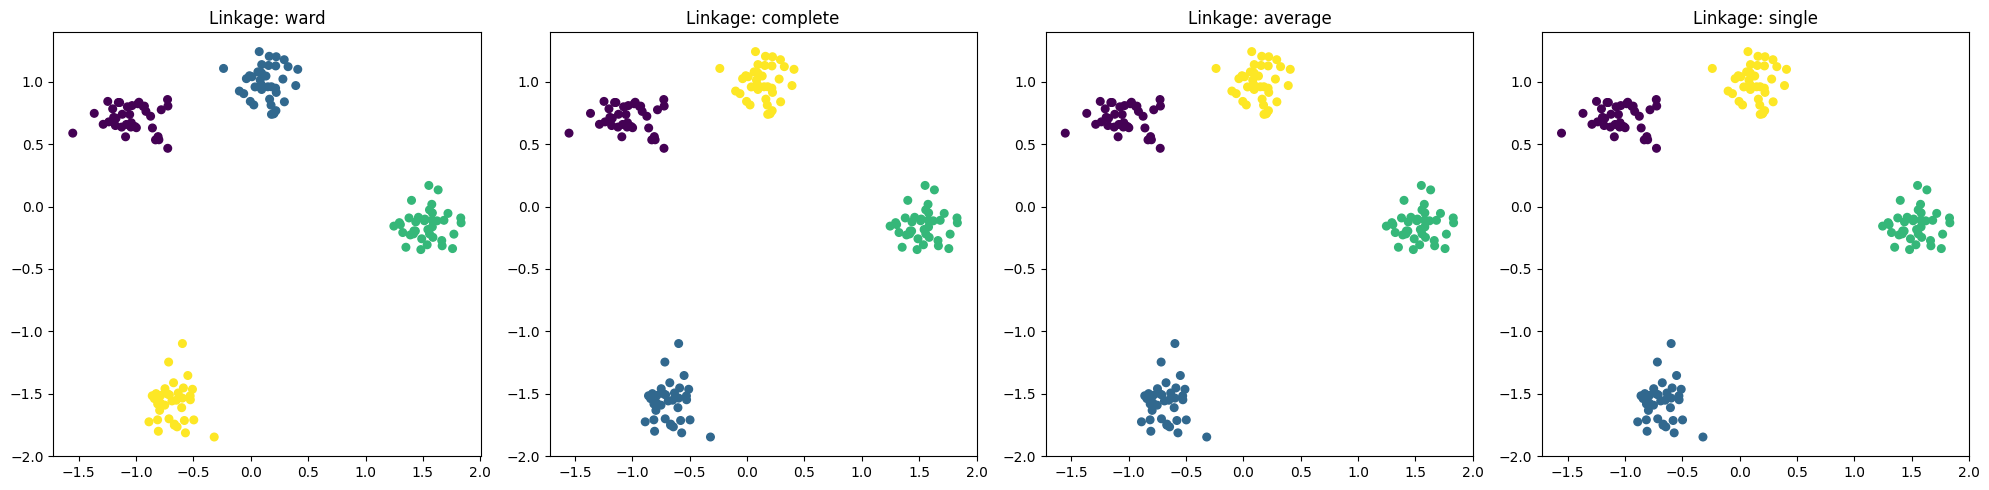

In [5]:
# 4. Compare different linkage methods
linkages = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, link in zip(axes, linkages):
    model = AgglomerativeClustering(n_clusters=4, linkage=link)
    labels = model.fit_predict(X)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
    ax.set_title(f"Linkage: {link}")
plt.tight_layout()
plt.show()

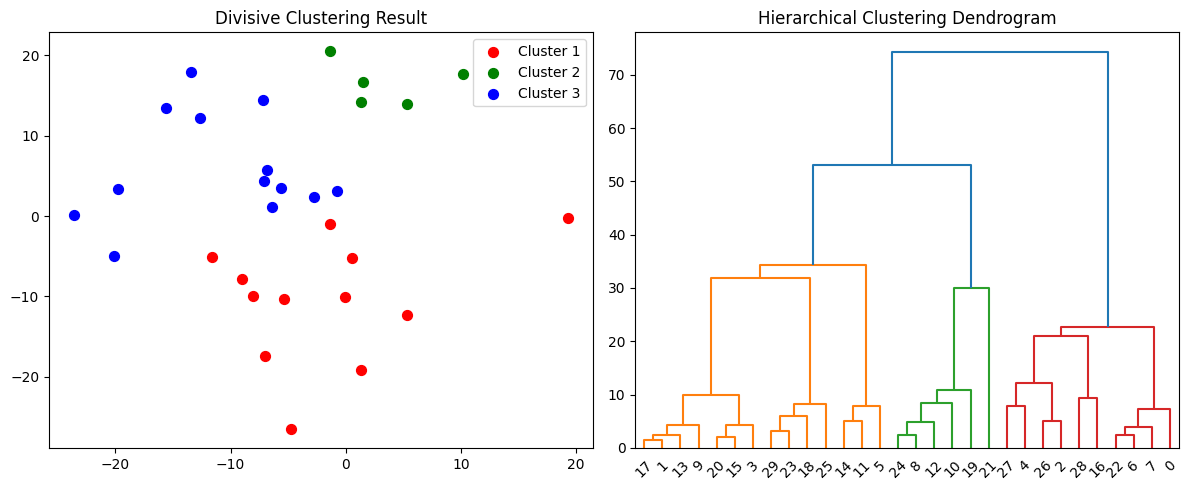

GFG Sample Code

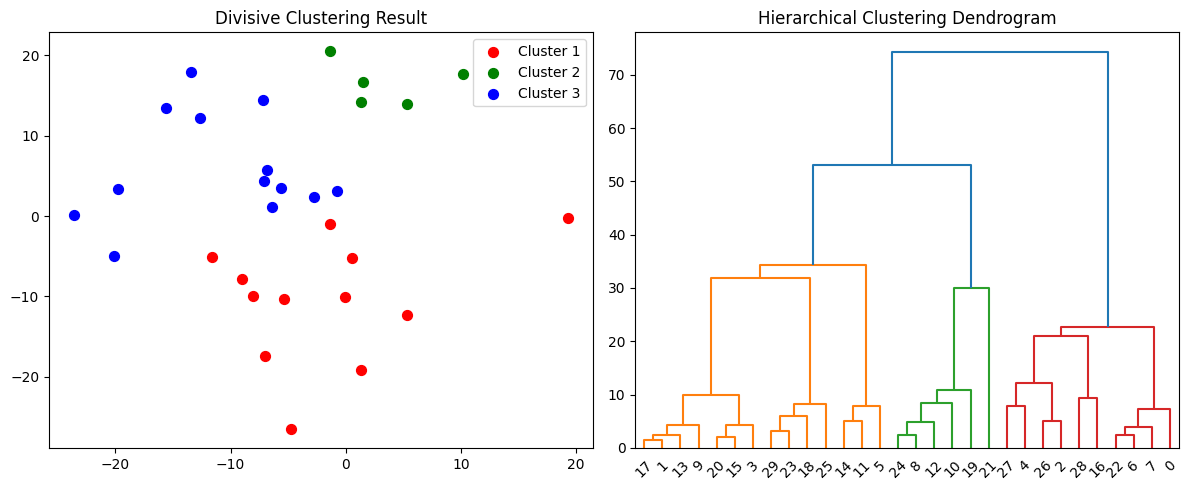

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage

X, _ = make_blobs(n_samples=30, centers=5, cluster_std=10, random_state=42)


def divisive_clustering(data, max_clusters=3):
    clusters = [data]
    while len(clusters) < max_clusters:
        cluster_to_split = max(clusters, key=lambda x: len(x))
        clusters.remove(cluster_to_split)

        kmeans = KMeans(n_clusters=2, random_state=42).fit(cluster_to_split)
        cluster1 = cluster_to_split[kmeans.labels_ == 0]
        cluster2 = cluster_to_split[kmeans.labels_ == 1]

        clusters.extend([cluster1, cluster2])
    return clusters


clusters = divisive_clustering(X, max_clusters=3)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['r', 'g', 'b', 'c', 'm', 'y']
for i, cluster in enumerate(clusters):
    plt.scatter(cluster[:, 0], cluster[:, 1], s=50,
                c=colors[i], label=f'Cluster {i+1}')
plt.title('Divisive Clustering Result')
plt.legend()

linked = linkage(X, method='ward')

plt.subplot(1, 2, 2)
dendrogram(linked, orientation='top',
           distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')

plt.tight_layout()
plt.show()